## Particle size distribution and viscosity calculations

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use given style
plt.style.use("james2026lock.mplstyle")

# import PSD data
data = pd.read_csv("../../data/metadata/clay_psd.csv", sep=",")
data = data[data["ultrasound_time"] == 0]  # only select the non-vibrated data

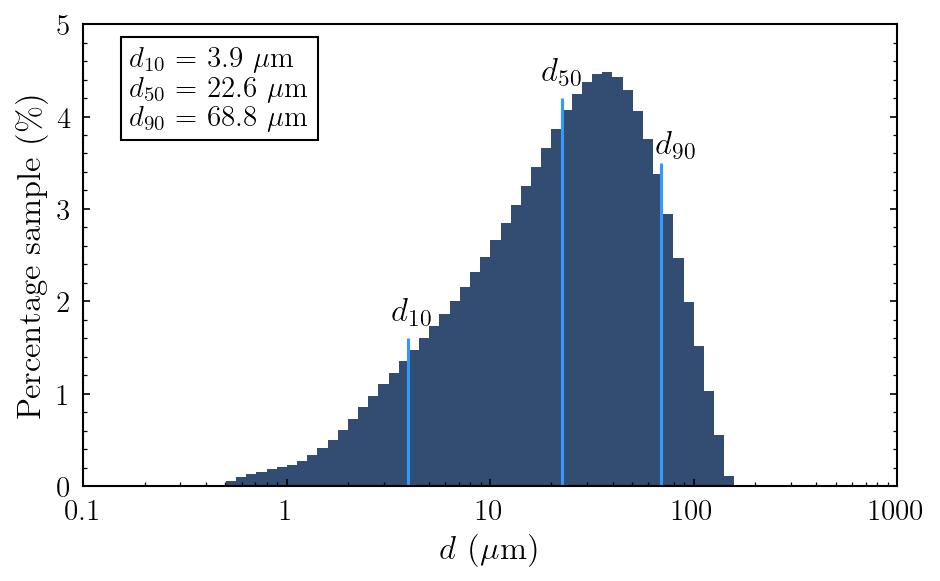

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))

# --- Bin geometry ---
edges = data["diameter_micron"].to_numpy()
x_center = (edges[1:] + edges[:-1]) / 2
x_widths = edges[1:] - edges[:-1]
percent = data["percent"].iloc[1:].to_numpy()

# --- Cumulative statistics ---
cumsum = np.cumsum(percent)
d10 = np.interp(10, cumsum, x_center)
d50 = np.interp(50, cumsum, x_center)
d90 = np.interp(90, cumsum, x_center)

# --- Plot bars ---
ax.bar(x_center, percent, width=x_widths, alpha=0.8, color="#001F4D")

# --- Percentile lines and labels ---
vline_xs = [d10, d50, d90]
vline_tops = [1.6, 4.2, 3.5]
ax.vlines(vline_xs, 0, vline_tops, color="#3399FF")

label_positions = [
    (3.3, 1.8, r"$d_{10}$"),
    (18, 4.4, r"$d_{50}$"),
    (65, 3.6, r"$d_{90}$"),
]
for x, y, label in label_positions:
    ax.text(x, y, label, fontsize=16)

# --- Stats text box ---
stats_text = "\n".join(
    [
        rf"$d_{{10}}$ = {d10:.1f} $\mu$m",
        rf"$d_{{50}}$ = {d50:.1f} $\mu$m",
        rf"$d_{{90}}$ = {d90:.1f} $\mu$m",
    ]
)

legend_box = dict(
    facecolor="white",
    edgecolor="black",
    alpha=1,
    boxstyle="round" if plt.rcParams["legend.fancybox"] else "square",
)
ax.text(0.17, 3.9, stats_text, fontsize=14, bbox=legend_box)

# --- Axes formatting ---
ax.set_xlim([0.1, 1000])
ax.set_ylim([0, 5])
ax.set_xscale("log")
ax.set_xticks([0.1, 1, 10, 100, 1000])
ax.set_xticklabels(["0.1", "1", "10", "100", "1000"])
ax.set_xlabel(r"$d\ (\mu\mathrm{m})$")
ax.set_ylabel(r"Percentage sample (\%)")
ax.grid()

# --- Save and show ---
plt.savefig("../figures/figure_S2.png", dpi=300, bbox_inches="tight")
plt.show()